In [2]:
# Ploting and data manage
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import folium
import seaborn as sns
import pandas as pd
from matplotlib import colors

# Machine learning algorithms and metrics
from sklearn.cluster import KMeans

import matplotlib.ticker as mticker
from sklearn.metrics import silhouette_score

import importlib
import sim_utils
importlib.reload(sim_utils)
from sim_utils import first_map, plot_map

import warnings
warnings.filterwarnings("ignore")

## Import geodataframes
1) **Boundaries**: Districts of Quebec city.
2) **Spots**: points containing Heart Attack events relevant information.

In [3]:
boundaries = gpd.read_file("boundaries.gpkg") 
boundaries.head()

,district,geometry
0,Les Rivières,"MULTIPOLYGON (((-71.26261 46.83542, -71.26082 ..."
1,La Haute-Saint-Charles,"MULTIPOLYGON (((-71.40996 46.95956, -71.40973 ..."
2,La Cité-Limoilou,"MULTIPOLYGON (((-71.26082 46.83348, -71.26261 ..."
3,Charlesbourg,"MULTIPOLYGON (((-71.32408 46.94312, -71.3239 4..."
4,Sainte-Foy - Sillery - Cap-Rouge,"MULTIPOLYGON (((-71.49475 46.80328, -71.49472 ..."


In [4]:
spots      = gpd.read_file('spots.gpkg')
spots.head()

,age,weight,income,disease,events,district,geometry
0,60,73,52.134220,AST,3,Les Rivières,POINT (-71.27628 46.82711)
1,67,65,57.211902,DBT,2,Les Rivières,POINT (-71.31865 46.84529)
2,62,72,42.991846,AST,2,Les Rivières,POINT (-71.32006 46.79838)
3,72,58,59.658490,AST,2,Les Rivières,POINT (-71.29996 46.82849)
4,58,75,47.622527,AST,1,Les Rivières,POINT (-71.33742 46.82991)


### Exploratory analysis

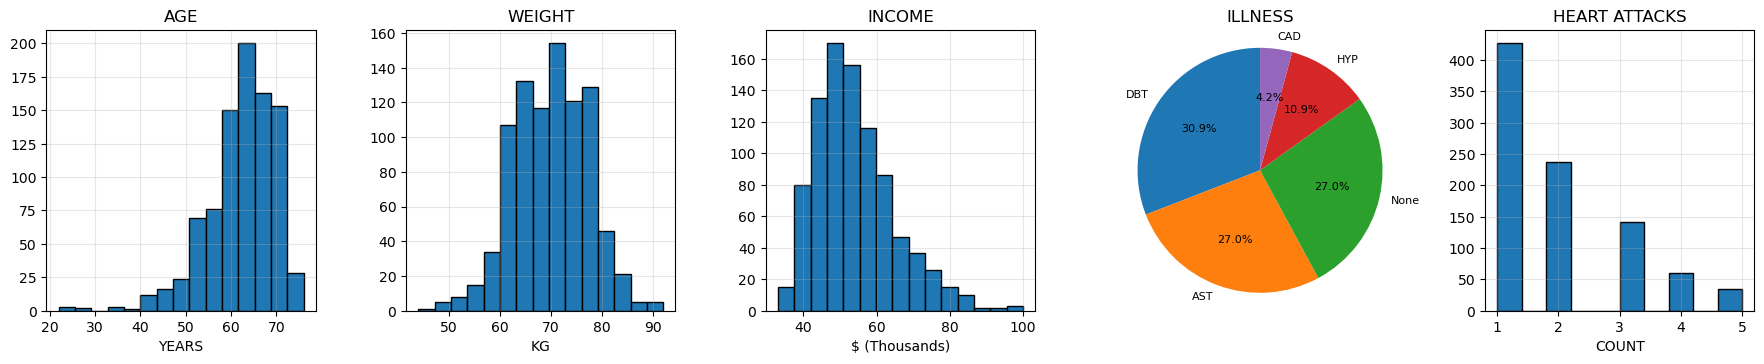

In [5]:
plt.figure(figsize=(18,4))

# AGE
plt.subplot(1,5,1)
plt.hist(spots['age'], bins=15, edgecolor="black")
plt.title('AGE')
plt.xlabel('YEARS')
plt.grid(alpha=0.3)

# WEIGHT
plt.subplot(1,5,2)
plt.hist(spots['weight'], bins=15, edgecolor="black")
plt.title('WEIGHT')
plt.xlabel('KG')
plt.grid(alpha=0.3)

# INCOME
plt.subplot(1,5,3)
plt.hist(spots['income'], bins=15, edgecolor="black")
plt.title('INCOME')
plt.xlabel('$ (Thousands)')
plt.grid(alpha=0.3)

# ILLNESS PIE
plt.subplot(1,5,4)

counts = spots['disease'].value_counts()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize':8}
)

plt.title('ILLNESS')
plt.axis('equal')

# EVENTS
plt.subplot(1,5,5)
plt.hist(spots['events'], bins=10, edgecolor="black")
plt.title('HEART ATTACKS')
plt.xlabel('COUNT')
plt.grid(alpha=0.3)

# spacing
plt.tight_layout(pad=2)

plt.show()

1) **AGE**: It's concentrated at older ages, with a long tail extending towards lower ages, aparently following a log-normal behavior.
2) **WEIGHT**: It's center around 70kg, resembling a normal distribution, with tails extending about 20kg away from the mean.
3) **INCOME**: It's concentrared about $50K, showing positive skewness, with a tial extending to nearly 100k dollars.
4) **ILLNESS**: It shows **Diabetis (DBT)** and **Asthma (AST)** as the dominant diseases with nearly 65% of the population suffering from them, and **Coronary artery disease (CAD)** and **Hypertension (HYP)** as less frequent, with a substantial fraction having neither (~20%).
5) **HEART ATTACKS**: HAs show skewness toward lower values, ranging from 1 to 13.

## Heart attack spatial distribution

In [6]:
map = plot_map(boundaries, spots)
#map

![Mapa de accesibilidad](Maps/MAP_1.png)
## Finding candidate locations
To find the set of candidate spots to build hospitals we will:
1) Find clusters using KMeans
2) Use the weighted centroids as potential candidates using the number of HA events as weighting factor



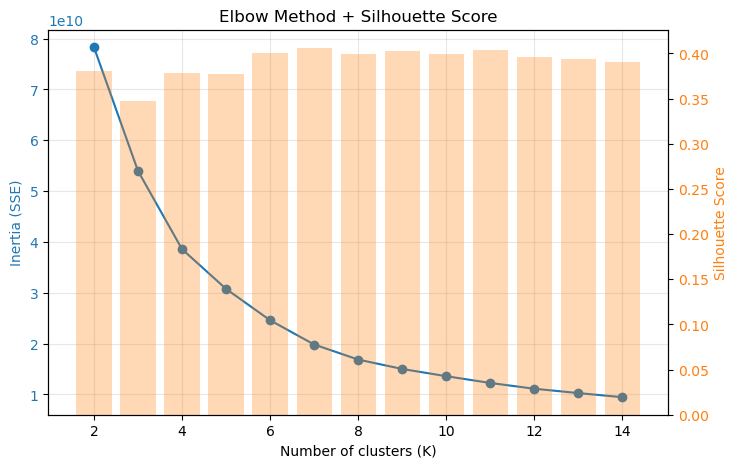

In [7]:
# Project spots on the plane
projected_spots = spots.to_crs(32198)

X = projected_spots.geometry.x
Y = projected_spots.geometry.y

coords = np.vstack([X, Y]).T

K_range = range(2, 15)  # silhouette does not work with K=1

inertias = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(coords, labels))

# ---- FIGURA ----
fig, ax1 = plt.subplots(figsize=(8,5))

# Elbow (inertia)
ax1.plot(K_range, inertias, marker='o', label='Inertia (SSE)')
ax1.set_xlabel("Number of clusters (K)")
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.set_ylabel("Inertia (SSE)", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Silhouette en segundo eje
ax2 = ax1.twinx()
ax2.bar(K_range, silhouettes, alpha=0.3, color='tab:orange', label='Silhouette')
ax2.set_ylabel("Silhouette Score", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Elbow Method + Silhouette Score")
plt.show()

Nor the elbow method neither the silhouette bars are visually conclusive.

### Second derivative method.
We compute the 2nd derivative and evaluate at 0, which will give is the break point where adding more hospitals do not change the curvature significantly.

In [8]:
inertias = np.array(inertias)

# 1st deriative
d1 = np.diff(inertias)

# 2nd derivative
d2 = np.diff(d1)

# maximum curvature
k_elbow = np.argmax(-d2) + 2  

print("K elbow:", k_elbow)

K elbow: 12


### Silhouette score
The highest silhouette is associated to the optimal number of clusters.

In [9]:
scores = []

K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords)
    
    score = silhouette_score(coords, labels)
    scores.append(score)

best_k = K_range[np.argmax(scores)]
print("best K:", best_k)

best K: 7


Both methods fail to converge to a clear agreement, suggesting that the data do not naturally form distinct clusters. The silhouette bars do not exhibit a significantly dominant peak, and the elbow method does not reveal a well-defined inflection point. Given this ambiguity, and in order to maximice the number of candidate sites, we select the largest value suggested by both approaches (k=12).

In [12]:
n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
projected_spots["cluster"] = kmeans.fit_predict(coords)

# Reproject back to WGS84
reprojected_spots = projected_spots.to_crs(4326)

map = plot_map(boundaries, reprojected_spots, use_clusters=True)
#map

![Mapa de accesibilidad](Maps/MAP_2.png)

## Determining candidate locations
Once clusters are known we will determine hospitals' candidate locations by computing the weighted centroid of each cluster using the number of HA events.

$$
X = \frac{\sum_i x_i \cdot n_i}{\sum_i n_i} \ \ \ \ \ Y = \frac{\sum_i y_i \cdot n_i}{\sum_i n_i}
$$

In [14]:
def weighted_centroid(group):

    n = group["events"]
    
    lat = np.average(group.geometry.y, weights=n)
    lon = np.average(group.geometry.x, weights=n)
    
    return pd.Series({"latitude": lat, "longitude": lon})

centroids = reprojected_spots.groupby("cluster").apply(weighted_centroid)
centroids

,latitude,longitude
cluster,,
0,46.726593,-71.224049
1,46.915337,-71.366673
2,46.818572,-71.233943
3,46.661477,-71.328393
4,46.831429,-71.455452
5,46.840790,-71.308912
6,46.780980,-71.103673
7,46.919377,-71.263585
8,46.658467,-71.189804


In [ ]:
# Save candidates
centroids.to_csv('candidate_spots.csv', index=False)

In [16]:
# Plot candidates
map = plot_map(boundaries, reprojected_spots, centroids, use_clusters=True)
#map

![Mapa de accesibilidad](Maps/MAP_3.png)


### Conclusion
We were able to identify 12 candidate locations for hospitals based on the spatial distribution of heart attack events in Quebec City. While no natural cluster emergerged from the data, as indicated by both the elbow and silhouette methods, K-Means is still useful not to reveal spatial structure but as a heuristic approach to discretize the spatial domain and generate representative candidate sites. 